# Scorecard — 01 Exploration

**Purpose.** Understand the data before building anything, and let what we find
justify the decisions in Phases 1–4. Every section ends with *"what this means
for the build"*.

A credit scorecard has to be explained to a credit committee and defended to a
regulator, so exploration here is not optional colour — it is the evidence trail
behind the modelling choices.

**Run order:** top to bottom. Restart and Run All before committing.

**Imports from `src/`** — no loader logic is duplicated here.


In [1]:
# --- Setup -------------------------------------------------------------------
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src.config import load_config
from src import load

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

config = load_config(REPO_ROOT / "config.yaml")
TARGET = config["schema"]["target_column"]
BAD_RAW = config["schema"]["bad_value_raw"]        # 2 = bad = default
print(f"config loaded | target column = '{TARGET}' | raw bad code = {BAD_RAW}")

config loaded | target column = 'target' | raw bad code = 2


In [2]:
# --- Load --------------------------------------------------------------------
# Same rule as the pipeline: the real UCI file if it's downloaded, else the
# committed sample (24 rows — fine for wiring, useless for conclusions).
data_cfg = config["data"]
raw_path = REPO_ROOT / data_cfg["raw_dir"] / data_cfg["raw_file"]

if raw_path.exists():
    df = load.load_german_raw(raw_path, config)
    print(f"Loaded REAL data: {raw_path.name}")
else:
    df = load.load_data(REPO_ROOT / data_cfg["sample_path"], config)
    print("Loaded the committed SAMPLE — numbers below are not meaningful.")
    print("Download the real file:", data_cfg["download_url"])

# One derived column used everywhere below: 1 = default, 0 = good.
# NOTE: this is a convenience for exploration only. The official recode, with the
# good/bad definition written down, happens in Phase 1 in src/load.py.
df["is_bad"] = (df[TARGET] == BAD_RAW).astype(int)

print(f"\n{len(df):,} applicants x {len(df.columns)} columns")
df.head(3)

Loaded REAL data: german.data

1,000 applicants x 22 columns


,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,num_liable,telephone,foreign_worker,target,is_bad
0,< 0 DM,6,critical account / credits elsewhere,radio / television,1169,unknown / no savings account,>= 7 years,4,male: single,none,4,real estate,67,none,own,2,skilled employee / official,1,registered in customer name,yes,1,0
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio / television,5951,< 100 DM,1 <= ... < 4 years,2,female: divorced / separated / married,none,2,real estate,22,none,own,1,skilled employee / official,1,none,yes,2,1
2,no checking account,12,critical account / credits elsewhere,education,2096,< 100 DM,4 <= ... < 7 years,2,male: single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,1,0


## 1. The target: how rare is default?

Every later metric choice follows from this number. With a minority class around
30%, plain accuracy is useless — a model predicting "everyone is good" would
score 70% and approve every bad loan. That is why Phase 5 uses KS, Gini/AUC and
PSI instead.

In [3]:
# --- Target balance ----------------------------------------------------------
counts = df[TARGET].value_counts().sort_index()
bad_rate = df["is_bad"].mean()

print("Raw target codes (1 = good, 2 = bad):")
for code, n in counts.items():
    print(f"  {code}: {n:,} ({n / len(df):.1%})")

print(f"\nOverall bad rate: {bad_rate:.1%}")
print(f"Good:bad odds:     {(1 - bad_rate) / bad_rate:.2f} : 1")
print(f"A 'predict everyone good' model would score {1 - bad_rate:.1%} accuracy "
      f"and catch 0 defaults.")

Raw target codes (1 = good, 2 = bad):
  1: 700 (70.0%)
  2: 300 (30.0%)

Overall bad rate: 30.0%
Good:bad odds:     2.33 : 1
A 'predict everyone good' model would score 70.0% accuracy and catch 0 defaults.


**What this means for the build.** Note the good:bad odds — Phase 6 scales
scores around a chosen reference odds (`scaling.base_odds` in config.yaml,
currently 50:1 at 600 points). Seeing the *actual* odds here tells you whether
that reference is sensible for this portfolio or inherited from a textbook.

## 2. Bad rate by category — the raw material of WOE

A scorecard is built on one idea: **does the bad rate differ across the levels of
a feature?** If it doesn't, the feature carries no information. Below is that
comparison for every categorical feature, which is exactly what Phase 3 turns
into Weight of Evidence.

In [4]:
# --- Bad rate by level, for each categorical feature -------------------------
cat_cols = [c for c in config["schema"]["categorical_columns"] if c in df.columns]

def bad_rate_table(frame, column, target="is_bad"):
    """Count, share of book, and bad rate for each level of one feature."""
    out = frame.groupby(column, observed=True).agg(
        accounts=(target, "size"),
        bads=(target, "sum"),
    )
    out["share_of_book"] = out["accounts"] / len(frame)
    out["bad_rate"] = out["bads"] / out["accounts"]
    return out.sort_values("bad_rate", ascending=False)

# Start with the one that is famously the strongest predictor in this dataset.
print("checking_status — bad rate by level:")
print(bad_rate_table(df, "checking_status").round(3).to_string())

checking_status — bad rate by level:
                                         accounts  bads  share_of_book  bad_rate
checking_status                                                                 
< 0 DM                                        274   135          0.274     0.493
0 <= ... < 200 DM                             269   105          0.269     0.390
>= 200 DM / salary assigned for 1+ year        63    14          0.063     0.222
no checking account                           394    46          0.394     0.117


In [5]:
# --- How much does each feature separate good from bad? ----------------------
# A quick, rough ranking: the spread between the worst and best level's bad rate,
# weighted by how much of the book sits in each. Information Value (Phase 3) does
# this properly; this is just to see which features are worth attention.
spreads = []
for col in cat_cols:
    table = bad_rate_table(df, col)
    usable = table[table["share_of_book"] >= 0.03]       # ignore tiny levels
    if len(usable) < 2:
        continue
    spreads.append({
        "feature": col,
        "levels": len(table),
        "worst_bad_rate": usable["bad_rate"].max(),
        "best_bad_rate": usable["bad_rate"].min(),
        "spread": usable["bad_rate"].max() - usable["bad_rate"].min(),
    })

ranking = pd.DataFrame(spreads).sort_values("spread", ascending=False)
print("Categorical features ranked by bad-rate spread (rough proxy for IV):")
print(ranking.round(3).to_string(index=False))

Categorical features ranked by bad-rate spread (rough proxy for IV):
                feature  levels  worst_bad_rate  best_bad_rate  spread
         credit_history       5           0.625          0.171   0.454
        checking_status       4           0.493          0.117   0.376
                purpose      10           0.440          0.165   0.275
          other_debtors       3           0.439          0.192   0.247
         savings_status       5           0.360          0.125   0.235
               property       4           0.435          0.213   0.222
         foreign_worker       2           0.307          0.108   0.199
       employment_since       5           0.407          0.224   0.183
                housing       3           0.407          0.261   0.147
other_installment_plans       3           0.410          0.275   0.135
    personal_status_sex       4           0.400          0.266   0.134
                    job       4           0.345          0.280   0.065
        

In [6]:
# --- Compute WOE and IV by hand, for ONE feature -----------------------------
# Doing this manually once is the point: in Phase 3 you will write code for it,
# and you need a number you trust to check that code against.
#
#   WOE_b = ln( %good_b / %bad_b )        IV = sum_b (%good_b - %bad_b) * WOE_b
#
feature = "checking_status"

t = df.groupby(feature, observed=True)["is_bad"].agg(bads="sum", accounts="size")
t["goods"] = t["accounts"] - t["bads"]
t["pct_good"] = t["goods"] / t["goods"].sum()
t["pct_bad"] = t["bads"] / t["bads"].sum()
t["woe"] = np.log(t["pct_good"] / t["pct_bad"])
t["iv_part"] = (t["pct_good"] - t["pct_bad"]) * t["woe"]

# WOE is undefined when a level has zero goods or zero bads: the ratio hits zero
# or infinity. Real scorecard practice merges such a level into a neighbour —
# one more reason for the minimum-bin-size rule in Phase 2.
if (t["goods"] == 0).any() or (t["bads"] == 0).any():
    print("WARNING: a level has zero goods or zero bads, so its WOE is undefined.")
    print("         Expected on the 24-row sample; on the full file it means that")
    print("         level must be merged in Phase 2.")
    print()

print(f"WOE / IV worked by hand for '{feature}':")
print(t.round(4).to_string())
print(f"\nInformation Value = {t['iv_part'].sum():.4f}")
print("Guide: <0.02 drop | 0.02-0.1 weak | 0.1-0.3 medium | 0.3-0.5 strong "
      "| >0.5 check for leakage")
print("\nKeep this number. Phase 3's code must reproduce it exactly.")

WOE / IV worked by hand for 'checking_status':
                                         bads  accounts  goods  pct_good  pct_bad     woe  iv_part
checking_status                                                                                   
0 <= ... < 200 DM                         105       269    164    0.2343   0.3500 -0.4014   0.0464
< 0 DM                                    135       274    139    0.1986   0.4500 -0.8181   0.2057
>= 200 DM / salary assigned for 1+ year    14        63     49    0.0700   0.0467  0.4055   0.0095
no checking account                        46       394    348    0.4971   0.1533  1.1763   0.4044

Information Value = 0.6660
Guide: <0.02 drop | 0.02-0.1 weak | 0.1-0.3 medium | 0.3-0.5 strong | >0.5 check for leakage

Keep this number. Phase 3's code must reproduce it exactly.


**What this means for the build.** Two things to carry forward. First, a
positive WOE means *more likely to be good* (that sign convention has to stay
consistent all the way to the points table, or your scorecard will be backwards).
Second, any level holding less than ~5% of the book is too thin to trust on its
own — which is precisely what `binning.min_bin_fraction` in config.yaml exists to
enforce in Phase 2.

## 3. Numeric features: is the bad rate monotonic?

Phase 2 coarse-classes each numeric feature into a few bins whose bad rate moves
in one direction. Monotonicity is what makes the final points table defensible:
*"longer loan term → more risk"* is explainable, while a bad rate that zig-zags
across bins is almost always noise being fitted.

In [7]:
# --- Bad rate by decile, for each numeric feature ----------------------------
num_cols = [c for c in config["schema"]["numeric_columns"] if c in df.columns]

def decile_bad_rate(frame, column, bins=5):
    """Cut a numeric column into quantile bins and show the bad rate per bin.

    duplicates="drop" handles columns with few distinct values (e.g. 1-4), where
    several quantile edges land on the same number.
    """
    binned = pd.qcut(frame[column], q=bins, duplicates="drop")
    out = frame.groupby(binned, observed=True).agg(
        accounts=("is_bad", "size"),
        bad_rate=("is_bad", "mean"),
    )
    return out

for col in num_cols:
    if df[col].nunique() < 3 or len(df) < 50:
        print(f"\n{col}: too few distinct values or rows to bin — skipped")
        continue
    table = decile_bad_rate(df, col)
    rates = table["bad_rate"].values
    direction = ("rising" if np.all(np.diff(rates) >= 0)
                 else "falling" if np.all(np.diff(rates) <= 0)
                 else "NOT monotonic")
    print(f"\n{col}  ->  {direction}")
    print(table.round(3).to_string())


duration_months  ->  NOT monotonic
                 accounts  bad_rate
duration_months                    
(3.999, 12.0]         359     0.212
(12.0, 15.0]           72     0.181
(15.0, 24.0]          339     0.322
(24.0, 30.0]           57     0.333
(30.0, 72.0]          173     0.480

credit_amount  ->  NOT monotonic
                   accounts  bad_rate
credit_amount                        
(249.999, 1262.0]       201     0.303
(1262.0, 1906.8]        199     0.241
(1906.8, 2852.4]        200     0.270
(2852.4, 4720.0]        200     0.260
(4720.0, 18424.0]       200     0.425

installment_rate  ->  rising
                  accounts  bad_rate
installment_rate                    
(0.999, 2.0]           367     0.262
(2.0, 3.0]             157     0.287
(3.0, 4.0]             476     0.334

residence_since  ->  falling
                 accounts  bad_rate
residence_since                    
(0.999, 2.0]          438     0.304
(2.0, 4.0]            562     0.297

age_years  ->  NOT mon

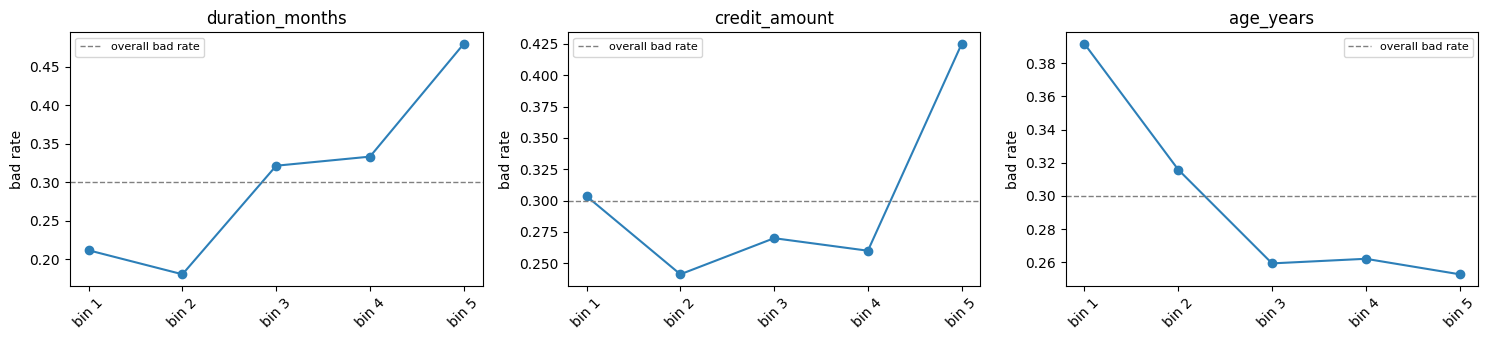

In [8]:
# --- Chart: bad rate across bins for the headline numeric features -----------
show = [c for c in ["duration_months", "credit_amount", "age_years"] if c in df.columns]

if len(df) >= 50 and show:
    fig, axes = plt.subplots(1, len(show), figsize=(5 * len(show), 3.5))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, show):
        table = decile_bad_rate(df, col)
        ax.plot(range(len(table)), table["bad_rate"].values, marker="o", color="#2c7fb8")
        ax.axhline(df["is_bad"].mean(), color="grey", linestyle="--", linewidth=1,
                   label="overall bad rate")
        ax.set_xticks(range(len(table)))
        ax.set_xticklabels([f"bin {i+1}" for i in range(len(table))], rotation=45)
        ax.set_title(col)
        ax.set_ylabel("bad rate")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough rows to chart — run on the real file.")

**What this means for the build.** Any feature flagged *NOT monotonic* is a
Phase 2 job: either the bins need merging, or the relationship genuinely isn't
monotonic and you'll have to decide between forcing it (safer, more explainable)
and leaving it free (fits better, harder to defend). Write down which features
are in that list — a panel will ask how you handled them.

## 4. Data quality, before anyone trusts a number

Cheap checks that prevent expensive surprises later.

In [9]:
# --- Duplicates, missingness, thin levels ------------------------------------
print(f"Exact duplicate rows: {df.duplicated().sum()}")

nulls = df.isna().sum()
nulls = nulls[nulls > 0]
print(f"Columns with missing values: {len(nulls)}")
if len(nulls):
    print(nulls.to_string())

print("\nLevels holding less than 5% of the book (too thin to bin alone):")
thin_total = 0
for col in cat_cols:
    share = df[col].value_counts(normalize=True)
    thin = share[share < 0.05]
    if len(thin):
        thin_total += len(thin)
        print(f"  {col}: {list(thin.index)}")
if thin_total == 0:
    print("  none")
print(f"\nTotal thin levels needing a merge in Phase 2: {thin_total}")

Exact duplicate rows: 0
Columns with missing values: 0

Levels holding less than 5% of the book (too thin to bin alone):
  credit_history: ['all credits at this bank paid back duly', 'no credits taken / all paid back duly']
  purpose: ['repairs', 'domestic appliances', 'other', 'retraining']
  savings_status: ['>= 1000 DM']
  other_debtors: ['co-applicant']
  other_installment_plans: ['stores']
  job: ['unemployed / unskilled non-resident']
  foreign_worker: ['no']

Total thin levels needing a merge in Phase 2: 11


## 5. The fair-lending question

`personal_status_sex` encodes sex, a protected attribute. The open decision in
`PROGRESS.md` is whether it enters the model at all. Look at the numbers before
deciding — and note that a feature being *predictive* is not an argument for
using it when the law says otherwise.

In [10]:
# --- Bad rate by a protected attribute ---------------------------------------
if "personal_status_sex" in df.columns:
    print(bad_rate_table(df, "personal_status_sex").round(3).to_string())
    print("\nQuestions to answer in Phase 3 and record in the methodology:")
    print("  1. Is this feature predictive enough to matter once others are in?")
    print("  2. Does dropping it meaningfully cost performance?")
    print("  3. Could a correlated feature reintroduce the same effect indirectly?")
else:
    print("Column not present — skipped.")

                                        accounts  bads  share_of_book  bad_rate
personal_status_sex                                                            
male: divorced / separated                    50    20          0.050     0.400
female: divorced / separated / married       310   109          0.310     0.352
male: married / widowed                       92    25          0.092     0.272
male: single                                 548   146          0.548     0.266

Questions to answer in Phase 3 and record in the methodology:
  1. Is this feature predictive enough to matter once others are in?
  2. Does dropping it meaningfully cost performance?
  3. Could a correlated feature reintroduce the same effect indirectly?


## 6. Findings to record

Copy your real numbers into `PROGRESS.md` under today's entry:

1. Overall bad rate and good:bad odds.
2. The three strongest categorical features by bad-rate spread.
3. Your hand-computed IV for `checking_status` — Phase 3 must reproduce it.
4. Which numeric features are **not** monotonic.
5. How many thin levels (<5% of book) need merging in Phase 2.

Items 3 and 4 are the ones that will save you time later: one is a test fixture,
the other is a to-do list for Phase 2.